In [2]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline
from pathlib import Path

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

Okay, now we go the big kahuna. We calculate thicknesses for each cell in each image, plot them, save sample figures, and iterate baby

In [28]:
# Experiment specifics
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
conds=["/ponA_mg_A3805"]

# Parameters
scale=500.0/762.0 # nm/pixel.
depth=300
opp_depth=int(10/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=5
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)

cond_ind=0

# Navigate to a specific condition
cond=conds[cond_ind]
dirs = [item.name for item in Path(base_path+expt_id+'/trace'+cond).iterdir() if item.is_dir() and item.name!='plots']

WT_sorb_10kX_0008
WT_sorb_10kX_0008_cell_2.csv


NameError: name 'spacing' is not defined

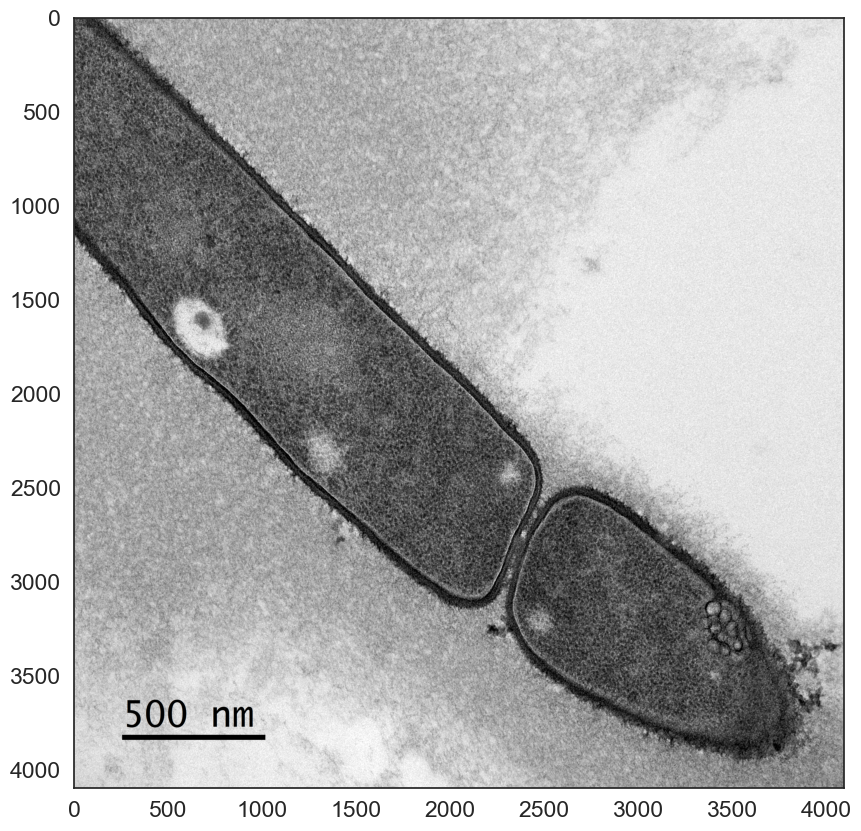

In [92]:
# Experiment specifics
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
conds=["/WT_sorb_A3802", "/ponA_mg_A3805", "/ponA_sorb_A3809", "/tago_mg_A3812", "/tago_sorb_A3815", "/WT_mg_A3799"]



# Parameters
scale=500.0/762.0 # nm/pixel.
depth=300
opp_depth=int(10/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=5
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)
num_fits=40
rel_val=0.7

col=['Condition', 'Cell number', 'Thickness (nm)']
cell_thickness_df=pd.DataFrame(columns=col)

for cond_ind in range(len(conds)):
    # Navigate to a specific condition
    cond=conds[cond_ind]
    dirs = [item.name for item in Path(base_path+expt_id+'/trace'+cond).iterdir() if item.is_dir() and item.name!='plots']
    # Work through all images from that condition
    cell_count=0
    for temp_dir in dirs:
        print(temp_dir)
        im1=io.imread(base_path+expt_id+cond+'/'+temp_dir+'.tif')
        im2=im1[:,:,0]
        # Plotting data
        sns.set_style('white')
        fig=plt.figure(figsize=[10,10])
        plt.imshow(im1)
        # Work through all traces from that image
        cell_traces_list= [item.name for item in Path(base_path+expt_id+'/trace'+cond+'/'+temp_dir).glob(temp_dir+'*.csv')]
        for name in cell_traces_list:
            print(name)
            coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+temp_dir+'/'+name)
            xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
            lam=10
            if len(xv)<5: # We need to have additional points to make a spline of this sort
                xv1,yv1=np.copy(xv),np.copy(yv)
                while len(xv1)<5:
                    xv1,yv1=xv1[np.argsort(xv1)],yv1[np.argsort(xv1)]
                    temp_x,temp_y=np.mean(xv1[:2]),np.mean(yv1[:2])
                    xv1,yv1=np.append(xv1,temp_x),np.append(yv1,temp_y)
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv1[np.argsort(xv1)], yv1[np.argsort(xv1)], lam=lam)
            else:
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
            xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/(num_fits+2))[1:-1]
            xnew1 = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/1000)
            ynew1=spl(xnew1)
            intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
            # Plotting spline values
            plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
            # Calculate intensity along transverse slices
            slopes=[]
            for ind in np.arange(len(xnew)):
                point=np.nonzero(xnew1>xnew[ind])[0][0]
                slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
                slopes.append(slope)
                num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
                xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
                xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
                yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
                if len(sel_vals[0])>cutoff_length:
                    intensity_vals[ind,sel_vals]=(255.0-im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])/255.0
    
            # Finding the first strong minimum after the first ~30nm which is < 2x the lowest value in the trace
            final_inds=[]
            for temp_int in range(intensity_vals.shape[0]):
                if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]:
                    signal=1.0-intensity_vals[temp_int,offset_ind:]
                    temp_peaks=scipy.signal.find_peaks(signal,width=2)
                    temp_proms=scipy.signal.peak_prominences(signal, temp_peaks[0], wlen=None)
                    temp_peaks1=np.asarray(temp_peaks[0])[np.nonzero(temp_proms[0]>cutoff)]
                    temp_vals=signal[temp_peaks1]>rel_val*np.nanmax(signal)
                    if np.sum(temp_vals)>0:
                        final_inds.append(temp_peaks1[np.nonzero(temp_vals)[0][0]]+offset_ind)
                    else:
                        final_inds.append(np.nan)
                else:
                    final_inds.append(np.nan)
                    
            for ind in np.arange(len(xnew)):
                if ~np.isnan(final_inds[ind]):
                    xs=np.sign(xv[-1]-xv[0])*np.sign(slopes[ind][0]) # determines whether x should increase or decrease.
                    yrange=float(spl(xnew1[point]))-1.0/slopes[ind][0]*(xrange-xnew1[point])
                    # now let's unit-spaced coordinates along this line, from start to end.
                    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slopes[ind][0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slopes[ind][0]))
                    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                    temp_xcoords=[xcoords[opp_depth],xcoords[final_inds[ind]]]
                    temp_ycoords=[ycoords[opp_depth],ycoords[final_inds[ind]]]
                    plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.6)
                    temp_df=pd.DataFrame(columns=col,data=[[cond[1:],cell_count,scale*(final_inds[ind]-opp_depth)]])
                    cell_thickness_df=pd.concat([cell_thickness_df,temp_df])
                cell_count+=1
        if not(os.path.isdir(base_path+expt_id+'/trace'+cond+'/plots')):
            os.mkdir(base_path+expt_id+'/trace'+cond+'/plots')
        fig.savefig(base_path+expt_id+'/trace'+cond+'/plots/'+temp_dir+'.png',bbox_inches='tight',dpi=150)
        plt.close()

In [75]:
cell_thickness_df.describe()

,Condition,Cell number,Thickness (nm)
count,7553,7553,7553.000000
unique,6,38,399.000000
top,tago_mg_A3812,9,38.057743
freq,1495,241,126.000000


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'WT_mg_A3799'),
  Text(1, 0, 'WT_sorb_A3802'),
  Text(2, 0, 'ponA_mg_A3805'),
  Text(3, 0, 'ponA_sorb_A3809'),
  Text(4, 0, 'tago_mg_A3812'),
  Text(5, 0, 'tago_sorb_A3815')])

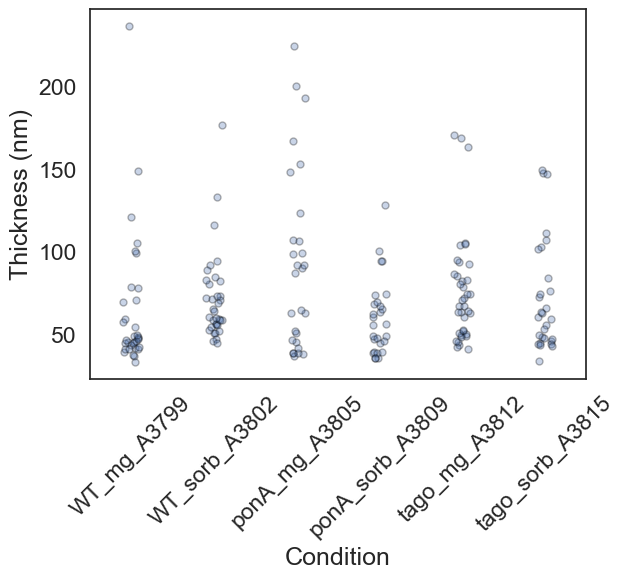

In [91]:
temp_df_out=cell_thickness_df.groupby(['Condition','Cell number'])['Thickness (nm)'].mean().reset_index()
plot = sns.stripplot(x='Condition', y='Thickness (nm)', data=temp_df_out, edgecolor='black', linewidth=1, native_scale=True, alpha=0.3, legend=False)
plt.xticks(rotation=45)

Okay, this is clearly not doing a good job. Let's see if we can improve matters by doing thresholding instead.

In [99]:
# Experiment specifics
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
conds=["/WT_sorb_A3802", "/ponA_mg_A3805", "/ponA_sorb_A3809", "/tago_mg_A3812", "/tago_sorb_A3815", "/WT_mg_A3799"]
threshs=(255.0-np.array([39,33,30,25,61,32]))/255.0
bkgds=(255.0-np.array([203.4,176.125,170,170,147,190]))/255.0


# Parameters
scale=500.0/762.0 # nm/pixel.
depth=300
opp_depth=int(10/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=9
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)
# num_fits=40
rel_val=0.7
spacing=4.0 # spacing in pixels between adjacent fits

col=['Condition', 'Cell number', 'Thickness (nm)']
cell_thickness_df=pd.DataFrame(columns=col)

for cond_ind in range(len(conds)):
    # Navigate to a specific condition
    cond=conds[cond_ind]
    bkgd=bkgds[cond_ind]
    peak_val=threshs[cond_ind]
    dirs = [item.name for item in Path(base_path+expt_id+'/trace'+cond).iterdir() if item.is_dir() and item.name!='plots']
    # Work through all images from that condition
    cell_count=0
    for temp_dir in dirs:
        print(temp_dir)
        im1=io.imread(base_path+expt_id+cond+'/'+temp_dir+'.tif')
        im2=im1[:,:,0]
        # Plotting data
        sns.set_style('white')
        fig=plt.figure(figsize=[10,10])
        plt.imshow(im1)
        # Work through all traces from that image
        cell_traces_list= [item.name for item in Path(base_path+expt_id+'/trace'+cond+'/'+temp_dir).glob(temp_dir+'*.csv')]
        for name in cell_traces_list:
            print(name)
            coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+temp_dir+'/'+name)
            xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
            lam=10
            if len(xv)<5: # We need to have additional points to make a spline of this sort
                xv1,yv1=np.copy(xv),np.copy(yv)
                while len(xv1)<5:
                    xv1,yv1=xv1[np.argsort(xv1)],yv1[np.argsort(xv1)]
                    temp_x,temp_y=np.mean(xv1[:2]),np.mean(yv1[:2])
                    xv1,yv1=np.append(xv1,temp_x),np.append(yv1,temp_y)
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv1[np.argsort(xv1)], yv1[np.argsort(xv1)], lam=lam)
            else:
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
            xnew = np.arange(np.amin(xv), np.amax(xv), spacing)[1:-1]
            xnew1 = np.arange(np.amin(xv), np.amax(xv), spacing/10.0)
            ynew1=spl(xnew1)
            intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
            # Plotting spline values
            plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
            # Calculate intensity along transverse slices
            slopes=[]
            for ind in np.arange(len(xnew)):
                point=np.nonzero(xnew1>xnew[ind])[0][0]
                slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
                slopes.append(slope)
                num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
                xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
                xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
                yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
                if len(sel_vals[0])>cutoff_length:
                    intensity_vals[ind,sel_vals]=(255.0-im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])/255.0
    
            # Let's just take the average over the first 30nm and find the first point where this intensity drops by 1/2 the difference 
            # between the peak 
            final_inds=[]
            for temp_int in range(intensity_vals.shape[0]):
                if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]:
                    signal=intensity_vals[temp_int,offset_ind:]

                    
                    # peak_val=np.nanmean(intensity_vals[temp_int,:offset_ind])
                    if np.sum(signal<(peak_val-0.5*(peak_val-bkgd)))>0:
                        final_inds.append(np.nonzero(signal<(peak_val-0.5*(peak_val-bkgd)))[0][0]+offset_ind)
                    else:
                        final_inds.append(np.nan)
                else:
                    final_inds.append(np.nan)
            # Finding the first strong minimum after the first ~30nm which is < 2x the lowest value in the trace
            
            # for temp_int in range(intensity_vals.shape[0]):
            #     if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]:
            #         signal=1.0-intensity_vals[temp_int,offset_ind:]
            #         temp_peaks=scipy.signal.find_peaks(signal,width=2)
            #         temp_proms=scipy.signal.peak_prominences(signal, temp_peaks[0], wlen=None)
            #         temp_peaks1=np.asarray(temp_peaks[0])[np.nonzero(temp_proms[0]>cutoff)]
            #         temp_vals=signal[temp_peaks1]>rel_val*np.nanmax(signal)
            #         if np.sum(temp_vals)>0:
            #             final_inds.append(temp_peaks1[np.nonzero(temp_vals)[0][0]]+offset_ind)
            #         else:
            #             final_inds.append(np.nan)
            #     else:
            #         final_inds.append(np.nan)
                    
            for ind in np.arange(len(xnew)):
                if ~np.isnan(final_inds[ind]):
                    xs=np.sign(xv[-1]-xv[0])*np.sign(slopes[ind][0]) # determines whether x should increase or decrease.
                    yrange=float(spl(xnew1[point]))-1.0/slopes[ind][0]*(xrange-xnew1[point])
                    # now let's unit-spaced coordinates along this line, from start to end.
                    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slopes[ind][0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slopes[ind][0]))
                    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                    temp_xcoords=[xcoords[opp_depth],xcoords[final_inds[ind]]]
                    temp_ycoords=[ycoords[opp_depth],ycoords[final_inds[ind]]]
                    plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.6)
                    temp_df=pd.DataFrame(columns=col,data=[[cond[1:],cell_count,scale*(final_inds[ind]-opp_depth)]])
                    cell_thickness_df=pd.concat([cell_thickness_df,temp_df])
            cell_count+=1
        if not(os.path.isdir(base_path+expt_id+'/trace'+cond+'/plots')):
            os.mkdir(base_path+expt_id+'/trace'+cond+'/plots')
        fig.savefig(base_path+expt_id+'/trace'+cond+'/plots/'+temp_dir+'.png',bbox_inches='tight',dpi=150)
        plt.close()

WT_sorb_10kX_0008
WT_sorb_10kX_0008_cell_2.csv
WT_sorb_10kX_0008_cell_1.csv
WT_sorb_10kX_0006
WT_sorb_10kX_0006_cell_1.csv
WT_sorb_10kX_0006_cell_3.csv
WT_sorb_10kX_0006_cell_2.csv
WT_sorb_10kX_0001
WT_sorb_10kX_0001_cell_2.csv
WT_sorb_10kX_0007
WT_sorb_10kX_0007_cell_1.csv
WT_sorb_10kX_0009
WT_sorb_10kX_0009_cell_2.csv
WT_sorb_10kX_0009_cell_1.csv
WT_sorb_10kX_0014
WT_sorb_10kX_0014_cell_3.csv
WT_sorb_10kX_0014_cell_2.csv
WT_sorb_10kX_0014_cell_1.csv
WT_sorb_10kX_0013
WT_sorb_10kX_0013_cell_1.csv
WT_sorb_10kX_0025
WT_sorb_10kX_0025_cell_1.csv
WT_sorb_10kX_0025_cell_2.csv
WT_sorb_10kX_0025_cell_3.csv
WT_sorb_10kX_0022
WT_sorb_10kX_0023
WT_sorb_10kX_0023_cell_2.csv
WT_sorb_10kX_0023_cell_1.csv
WT_sorb_10kX_0024
WT_sorb_10kX_0024_cell_1.csv
WT_sorb_10kX_0012
WT_sorb_10kX_0012_cell_1.csv
WT_sorb_10kX_0012_cell_2.csv
WT_sorb_10kX_0015
WT_sorb_10kX_0015_cell_1.csv
WT_sorb_10kX_0005
WT_sorb_10kX_0005_cell_1.csv
WT_sorb_10kX_0003
WT_sorb_10kX_0003_cell_2.csv
WT_sorb_10kX_0003_cell_1.csv
WT_so

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'WT_mg_A3799'),
  Text(1, 0, 'WT_sorb_A3802'),
  Text(2, 0, 'ponA_mg_A3805'),
  Text(3, 0, 'ponA_sorb_A3809'),
  Text(4, 0, 'tago_mg_A3812'),
  Text(5, 0, 'tago_sorb_A3815')])

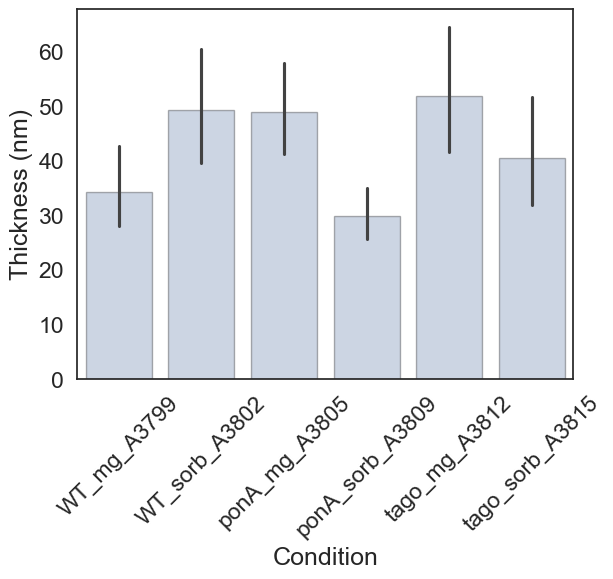

In [98]:
temp_df_out=cell_thickness_df.groupby(['Condition','Cell number'])['Thickness (nm)'].median().reset_index()
plot = sns.barplot(x='Condition', y='Thickness (nm)', data=temp_df_out, edgecolor='black', linewidth=1, native_scale=True, alpha=0.3, legend=False)
plt.xticks(rotation=45)

This is proving difficult. The trouble is that things really qualitatively look quite different between strains (as well as the segmentation failing). Let's try something else. Can we generate an "average profile" for a given cell type?